In [1]:
import pandas as pd
import numpy as np

In [2]:
i_cols = ['movie id', 'movie title' ,'release date', 'video release date', 'IMDb URL', 'unknown', 'Action', 'Adventure', 'Animation', "Children's", 
          'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
          'War', 'Western']

movies_df = pd.read_csv('ml-100k/u.item', sep='|', names=i_cols, encoding='latin-1')

In [3]:
ratings_df = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id','movie_id','rating','unix_timestamp'])

In [4]:
popular_movies = (ratings_df.groupby('movie_id')['rating'].count().sort_values(ascending=False))

In [5]:
movies_df['popularity_score'] = (movies_df['movie id'].map(popular_movies))

In [6]:
top_action_movies = (movies_df[movies_df['Action']==1].sort_values(by='popularity_score',ascending=False))

In [7]:
top_action_movies[['movie title','popularity_score']].head(10)

,movie title,popularity_score
49,Star Wars (1977),583
180,Return of the Jedi (1983),507
299,Air Force One (1997),431
120,Independence Day (ID4) (1996),429
173,Raiders of the Lost Ark (1981),420
126,"Godfather, The (1972)",413
116,"Rock, The (1996)",378
171,"Empire Strikes Back, The (1980)",367
221,Star Trek: First Contact (1996),365
312,Titanic (1997),350


### Top 10 Comedy Movies

In [8]:
top_comedy_movies = (movies_df[movies_df['Comedy'] == 1].sort_values(by='popularity_score',ascending=False))
top_comedy_movies[['movie title','popularity_score']].head(10)

,movie title,popularity_score
293,Liar Liar (1997),485
0,Toy Story (1995),452
203,Back to the Future (1985),350
150,Willy Wonka and the Chocolate Factory (1971),326
172,"Princess Bride, The (1987)",324
68,Forrest Gump (1994),321
167,Monty Python and the Holy Grail (1974),316
268,"Full Monty, The (1997)",315
256,Men in Black (1997),303
24,"Birdcage, The (1996)",293


### Top 10 Drama Movies

In [9]:
top_drama_movies = (movies_df[movies_df['Drama'] == 1].sort_values(by='popularity_score',ascending=False))
top_drama_movies[['movie title','popularity_score']].head(10)

,movie title,popularity_score
257,Contact (1997),509
99,Fargo (1996),508
285,"English Patient, The (1996)",481
126,"Godfather, The (1972)",413
55,Pulp Fiction (1994),394
6,Twelve Monkeys (1995),392
97,"Silence of the Lambs, The (1991)",390
236,Jerry Maguire (1996),384
171,"Empire Strikes Back, The (1980)",367
312,Titanic (1997),350


### Overall Most Popular Movies

In [10]:
movies_df.sort_values(by='popularity_score',ascending=False)[['movie title','popularity_score']].head(10)

,movie title,popularity_score
49,Star Wars (1977),583
257,Contact (1997),509
99,Fargo (1996),508
180,Return of the Jedi (1983),507
293,Liar Liar (1997),485
285,"English Patient, The (1996)",481
287,Scream (1996),478
0,Toy Story (1995),452
299,Air Force One (1997),431
120,Independence Day (ID4) (1996),429


### Visualization

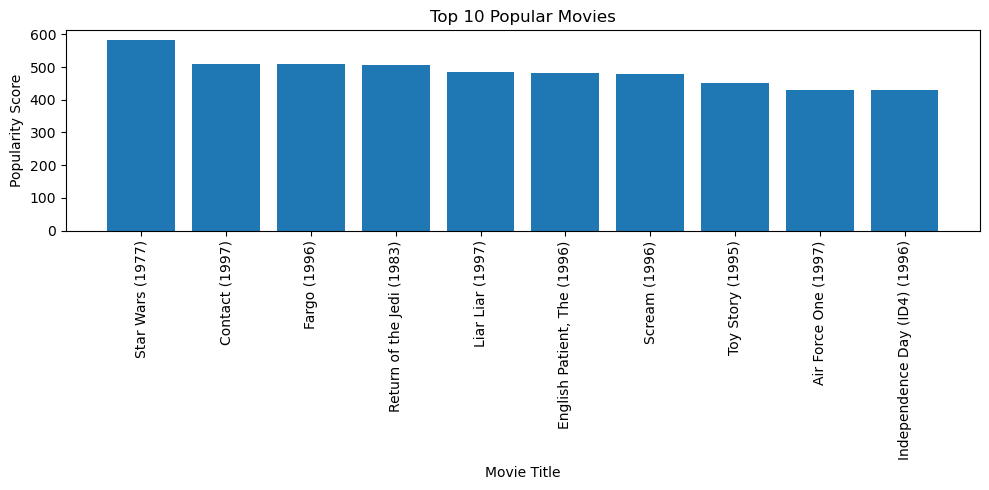

In [11]:
import matplotlib.pyplot as plt

top_movies = movies_df.sort_values(by='popularity_score',ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_movies['movie title'],top_movies['popularity_score'])

plt.xticks(rotation=90)

plt.xlabel("Movie Title")
plt.ylabel("Popularity Score")
plt.title("Top 10 Popular Movies")

plt.tight_layout()
plt.show()

### Popularity Recommendation

In [12]:
def recommend_popular_movies(genre_name):
    genre_movies = (movies_df[movies_df[genre_name] == 1].sort_values(by='popularity_score', ascending=False))
    return genre_movies[['movie title','popularity_score']].head(5)

In [13]:
recommend_popular_movies('Action')

,movie title,popularity_score
49,Star Wars (1977),583
180,Return of the Jedi (1983),507
299,Air Force One (1997),431
120,Independence Day (ID4) (1996),429
173,Raiders of the Lost Ark (1981),420


In [14]:
recommend_popular_movies('Comedy')

,movie title,popularity_score
293,Liar Liar (1997),485
0,Toy Story (1995),452
203,Back to the Future (1985),350
150,Willy Wonka and the Chocolate Factory (1971),326
172,"Princess Bride, The (1987)",324


In [15]:
recommend_popular_movies('Drama')

,movie title,popularity_score
257,Contact (1997),509
99,Fargo (1996),508
285,"English Patient, The (1996)",481
126,"Godfather, The (1972)",413
55,Pulp Fiction (1994),394
